In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt


params = {
    'figure.figsize': (7, 5),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

In [2]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))

# names of variables
design_vars = [s + " meas" for s in species] + controls

In [3]:
# File path
csv_path = "space/predictions.csv"

# Pattern to match
target_substring = "4Inulin-1Pectin-1Xylan"

# Column name that contains the experiment name
experiment_col = "Experiments"

# Store filtered chunks
filtered_chunks = []

# Set a reasonable chunk size (adjust based on available memory)
chunk_size = 100_000

# Iterate through the CSV file in chunks
for chunk in tqdm(pd.read_csv(csv_path, chunksize=chunk_size)):

    # Filter the chunk for matching experiment names
    mask = chunk[experiment_col].str.contains(target_substring, na=False)
    filtered = chunk[mask]

    # Save the filtered chunk (in memory or to file)
    if not filtered.empty:
        filtered_chunks.append(filtered)

# Concatenate all filtered chunks into a single DataFrame
result_df = pd.concat(filtered_chunks, ignore_index=True)

0it [00:00, ?it/s]

606it [01:17,  7.84it/s]


In [4]:
result_df.columns.values

array(['Experiments', 'Time', 'ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs',
       'CAabs', 'CCabs', 'CHabs', 'DFabs', 'ELabs', 'ERabs', 'FPabs',
       'PCabs', 'PJabs', 'RIabs', 'pH', 'Lactate', 'Butyrate', 'Acetate',
       'AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan'],
      dtype=object)

In [5]:
# log that ignores zeros
def zlog(x):
    x[x <= 0] = 1
    return np.log(x)

# shannon diversity
def shannon(y):
    y = np.clip(y, 0, np.inf)
    if np.nansum(y) > 0:
        y_rel = y / np.nansum(y)
        return np.nansum(-zlog(y_rel)*y_rel)
    else:
        return np.nan

# determine best previously observed values of objectives
b_max = 24.206144
d_max = 2.2569
v_max = 0.05319

# define objective 
def objective(y):
    # y is measured exp data [n_time, n_species + n_metabolites]

    # endpoint shannon diversity
    diversity = shannon(y[-1, :len(species)])

    # variance in species abundances in last two passages
    species_stdv = np.std(y[-2:, :len(species)], 0)
    instability  = np.where(species_stdv>0, species_stdv, 0).mean() 

    # endpoint butyrate production 
    butyrate =  y[-1, -2]   

    # scaled objective 
    scaled_obj = diversity / d_max - instability / v_max + butyrate / b_max

    return diversity, instability, butyrate, scaled_obj

In [6]:
# compute measured objectives 
exp_objs = {}
for exp_name, df_exp in tqdm(result_df.groupby("Experiments")):
    exp_objs[exp_name] = objective(df_exp[species+metabolites].values)

100%|██████████| 32767/32767 [00:04<00:00, 7239.53it/s]


In [7]:
# plot distribution of objectives 
exp, obj = zip(*exp_objs.items())
unique_experiments = np.array(exp) 
objectives = np.array(obj)

In [8]:
objectives.shape

(32767, 4)

In [9]:
worst_condition_idx = np.nanargmin(objectives[:, -1])
worst_condition = unique_experiments[worst_condition_idx]
worst_condition

np.str_('BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan')

In [11]:
best_condition_idx = np.nanargmax(objectives[:, -1])
best_condition = unique_experiments[best_condition_idx]
best_condition

np.str_('AC-BA-BH-BU-DF-ER-FP-RI-4Inulin-1Pectin-1Xylan')

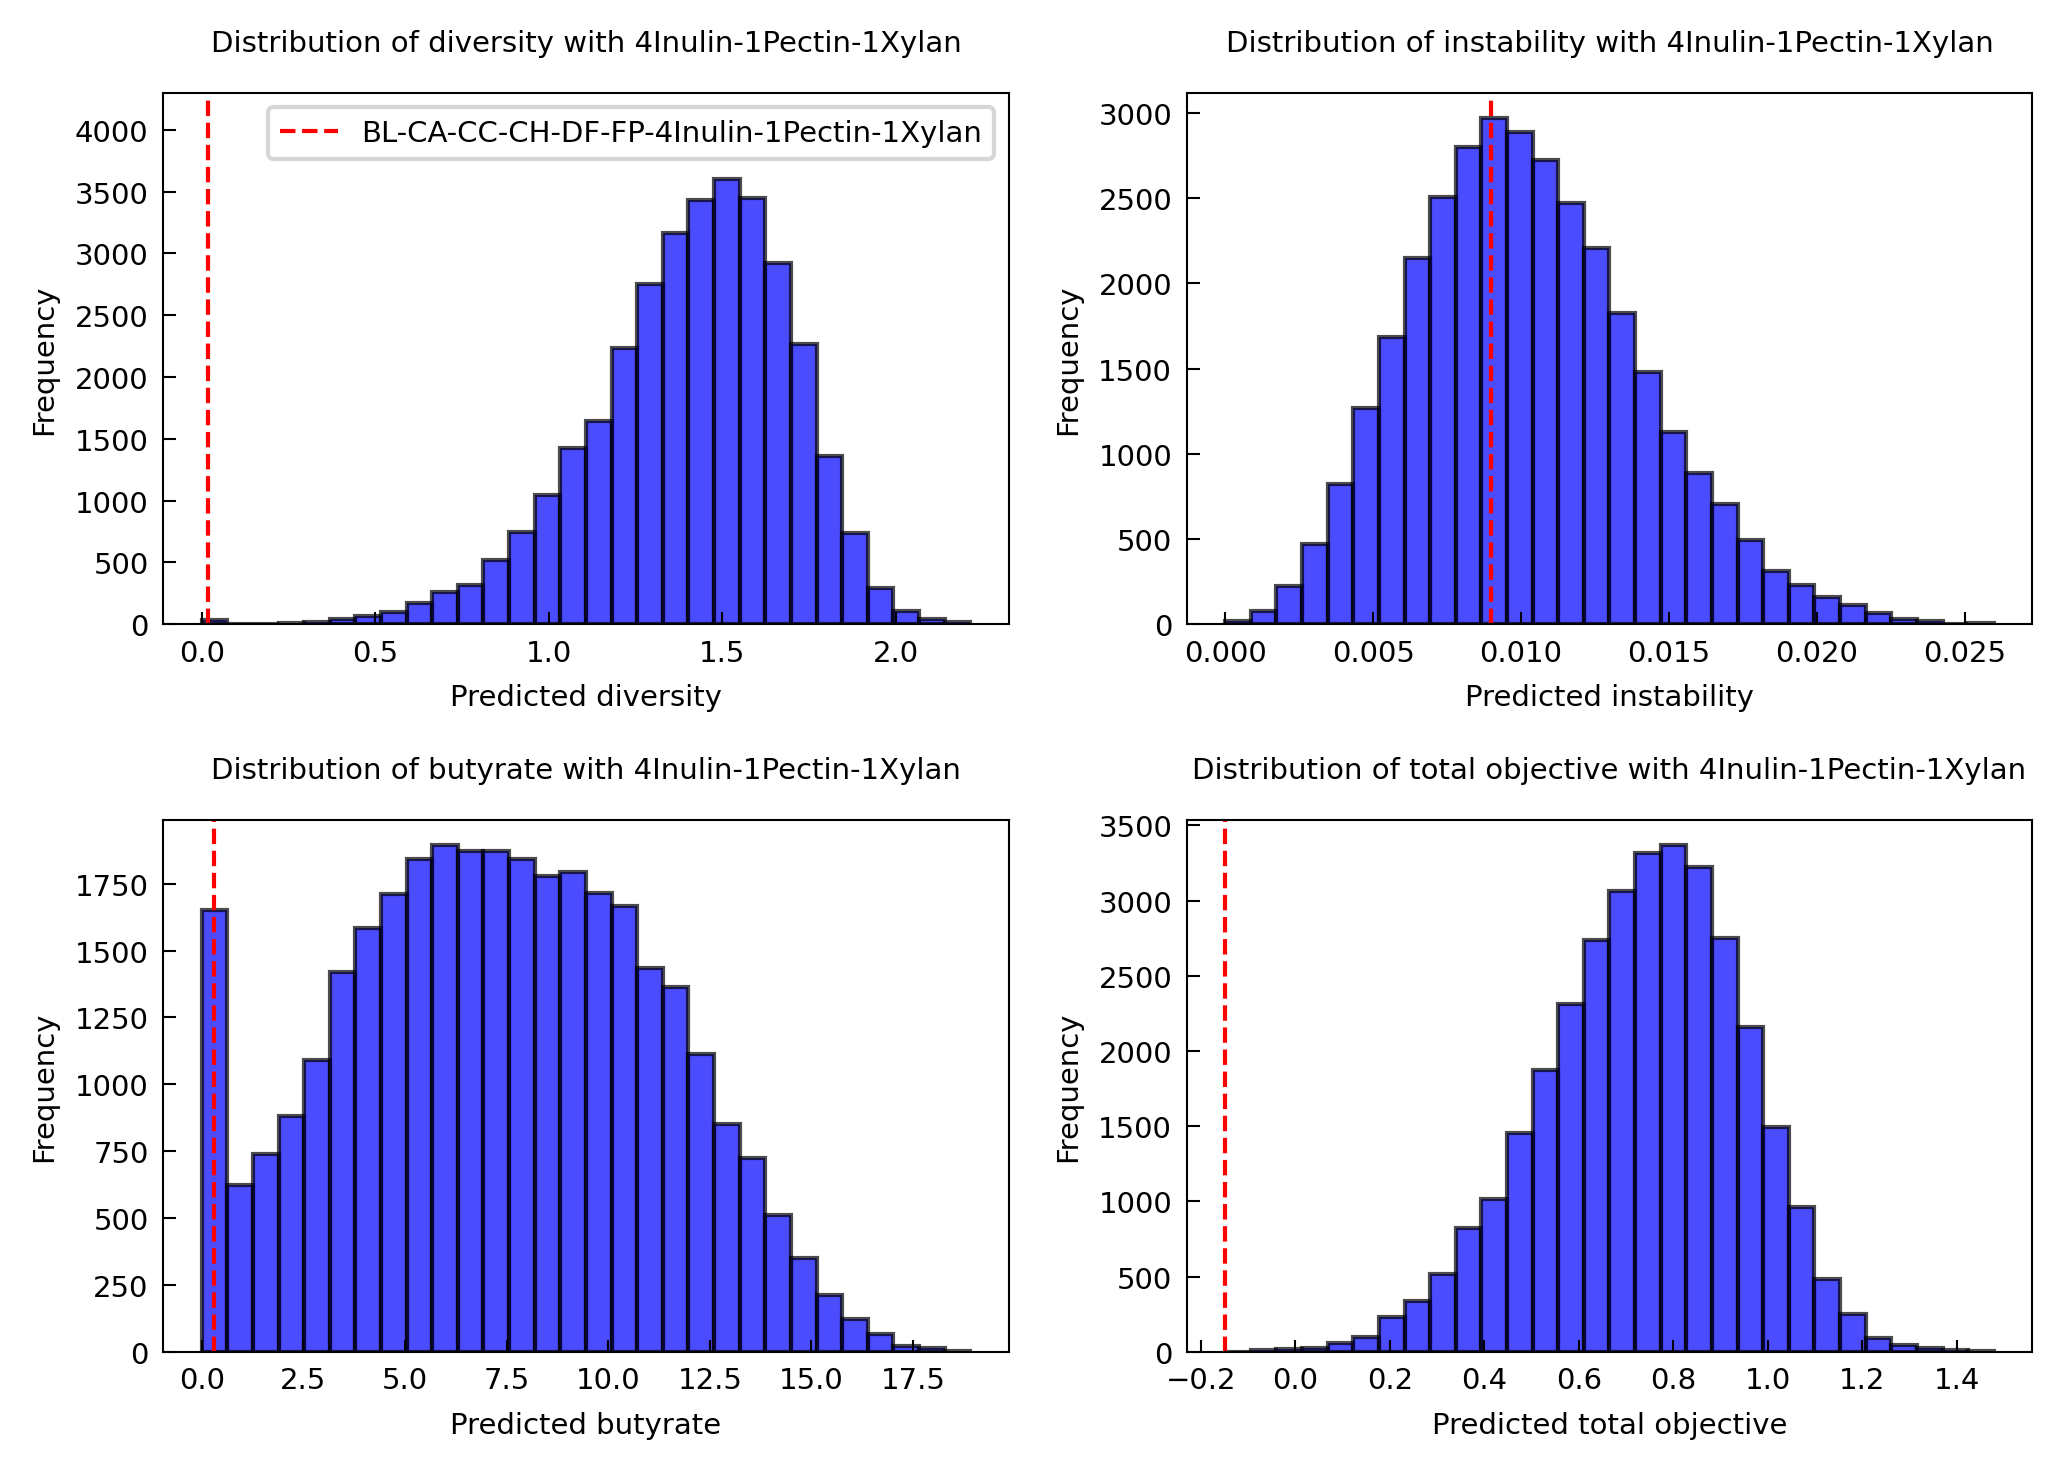

In [10]:
# plot distribution of objectives
titles = ['diversity', 'instability', 'butyrate', 'total objective']

for j, title in enumerate(titles):

    plt.subplot(2,2,j+1)
    plt.hist(objectives[:,j], bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel(f'Predicted {titles[j]}')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {titles[j]} with 4Inulin-1Pectin-1Xylan')
    if j == 0:
        plt.axvline(objectives[worst_condition_idx, j], color='red', linestyle='dashed', linewidth=1, label=worst_condition)
        plt.legend()
        plt.ylim([0, 4300])
    else:
        plt.axvline(objectives[worst_condition_idx, j], color='red', linestyle='dashed', linewidth=1)

plt.tight_layout()
plt.savefig('LoComm_IPX.svg', dpi=300)
plt.savefig('LoComm_IPX.png', dpi=300)
plt.show()

In [54]:
worst_df = result_df[result_df['Experiments'] == worst_condition]
worst_df.to_csv('LoComm_IPX.csv', index=False)
# save the worst condition to a csv file
worst_df.head()

,Experiments,Time,ACabs,BAabs,BHabs,BLabs,BUabs,CAabs,CCabs,CHabs,...,pH,Lactate,Butyrate,Acetate,AcGum,ArGal,Inulin,Pectin,Starch,Xylan
12060,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,0.0,0.0,0.0,0.0,0.000667,0.0,0.000667,0.000667,0.000667,...,6.700000,0.000000,0.000000,0.000000,0.0,0.0,0.666667,0.166667,0.0,0.166667
12061,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,1.0,0.0,0.0,0.0,0.182314,0.0,0.021128,0.136136,0.116957,...,6.560126,2.395823,4.727830,24.796773,0.0,0.0,0.666667,0.166667,0.0,0.166667
12062,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,2.0,0.0,0.0,0.0,0.300058,0.0,0.000000,0.093804,0.011662,...,6.880385,NaN,NaN,NaN,0.0,0.0,0.666667,0.166667,0.0,0.166667
12063,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,3.0,0.0,0.0,0.0,0.437847,0.0,0.000000,0.000000,0.000000,...,6.704691,4.028980,0.304627,17.108248,0.0,0.0,0.666667,0.166667,0.0,0.166667


In [ ]:
worst_df = result_df[result_df['Experiments'] == worst_condition]
worst_df.to_csv('LoComm_IPX.csv', index=False)
# save the worst condition to a csv file
worst_df.head()

,Experiments,Time,ACabs,BAabs,BHabs,BLabs,BUabs,CAabs,CCabs,CHabs,...,pH,Lactate,Butyrate,Acetate,AcGum,ArGal,Inulin,Pectin,Starch,Xylan
12060,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,0.0,0.0,0.0,0.0,0.000667,0.0,0.000667,0.000667,0.000667,...,6.700000,0.000000,0.000000,0.000000,0.0,0.0,0.666667,0.166667,0.0,0.166667
12061,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,1.0,0.0,0.0,0.0,0.182314,0.0,0.021128,0.136136,0.116957,...,6.560126,2.395823,4.727830,24.796773,0.0,0.0,0.666667,0.166667,0.0,0.166667
12062,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,2.0,0.0,0.0,0.0,0.300058,0.0,0.000000,0.093804,0.011662,...,6.880385,NaN,NaN,NaN,0.0,0.0,0.666667,0.166667,0.0,0.166667
12063,BL-CA-CC-CH-DF-FP-4Inulin-1Pectin-1Xylan,3.0,0.0,0.0,0.0,0.437847,0.0,0.000000,0.000000,0.000000,...,6.704691,4.028980,0.304627,17.108248,0.0,0.0,0.666667,0.166667,0.0,0.166667


In [56]:
# hicomm-ipx 
hicomm_ipx = 'AC-BA-BH-BL-BU-CH-DF-FP-RI-4Inulin-1Pectin-1Xylan'
hicomm_ipx_df = result_df[result_df['Experiments'] == hicomm_ipx] 

In [64]:
best_condition_idx = np.argmax(np.array(exp)==hicomm_ipx) 

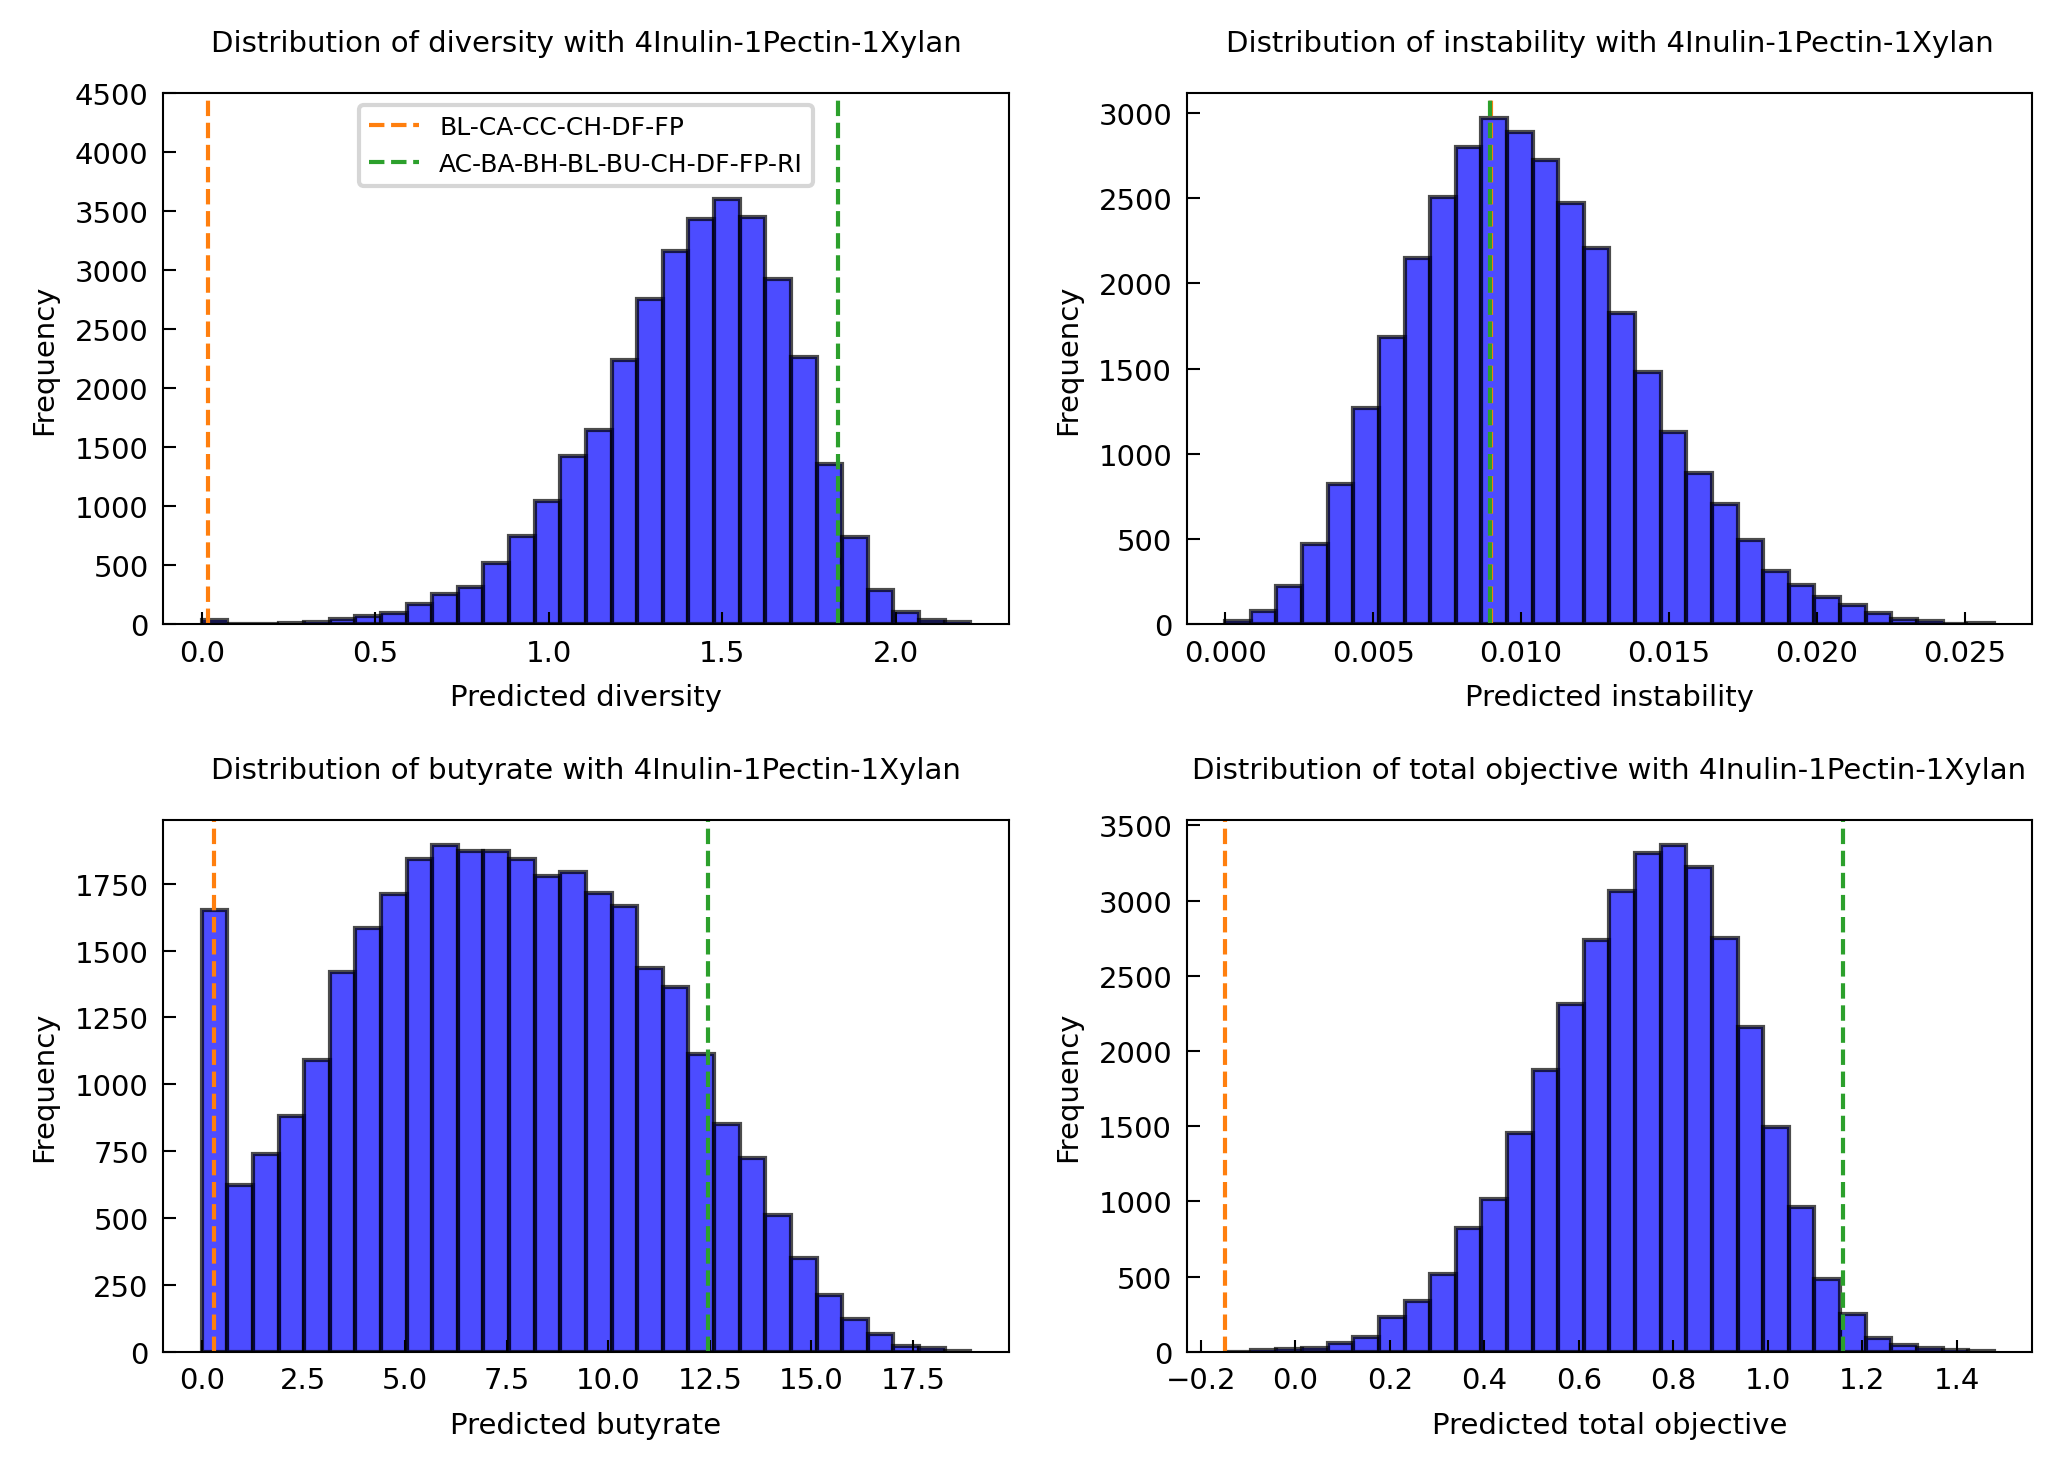

In [70]:
# plot distribution of objectives
titles = ['diversity', 'instability', 'butyrate', 'total objective']

for j, title in enumerate(titles):

    plt.subplot(2,2,j+1)
    plt.hist(objectives[:,j], bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel(f'Predicted {titles[j]}')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {titles[j]} with 4Inulin-1Pectin-1Xylan')
    if j == 0:
        plt.axvline(objectives[worst_condition_idx, j], color='C1', linestyle='dashed', linewidth=1, label=worst_condition.split("-4I")[0])
        plt.axvline(objectives[best_condition_idx, j], color='C2', linestyle='dashed', linewidth=1, label=hicomm_ipx.split("-4I")[0])
        plt.legend(fontsize=6, loc='best')
        plt.ylim([0, 4500])
    else:
        plt.axvline(objectives[worst_condition_idx, j], color='C1', linestyle='dashed', linewidth=1)
        plt.axvline(objectives[best_condition_idx, j], color='C2', linestyle='dashed', linewidth=1)

plt.tight_layout()
plt.savefig('LoComm_vs_HiComm_IPX.svg', dpi=300)
plt.savefig('LoComm_vs_HiComm_IPX.png', dpi=300)
plt.show()